In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import warnings
import time

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (roc_auc_score, brier_score_loss,
                             precision_recall_curve, roc_curve,
                             average_precision_score)

# Calibration curve helpers
from sklearn.calibration import calibration_curve
%matplotlib inline
warnings.filterwarnings('ignore', category=FutureWarning)

BASE_DIR = "../"
DATA_PATH = os.path.join(BASE_DIR, "data", "cancer_data_eng.csv")
IMG_DIR = os.path.join(BASE_DIR, "img.myself")
RESULTS_DIR = os.path.join(BASE_DIR, "result.myself")

os.makedirs(IMG_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)
RANDOM_STATE = 42
N_SAMPLES = 20000

plt.rcParams['font.sans-serif'] = [ 'Microsoft YaHei','SimHei', 'DejaVu Sans', 'Arial']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
from sklearn.preprocessing import OrdinalEncoder
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

print("\n[0] 加载数据...")
df = pd.read_csv(DATA_PATH, low_memory=False, encoding='latin-1')
df['target'] = df['Status.Vital'].map({'VIVO': 1, 'MORTO': 0})
df = df.dropna(subset=['target'])

np.random.seed(RANDOM_STATE)
if len(df) > N_SAMPLES:
    idx = np.random.choice(len(df), N_SAMPLES, replace=False)
    df = df.iloc[idx].copy()

feature_cols = ['Age', 'year', 'Code.Profession', 'Diagnostic.means',
                'Extension', 'Raca.Color']
cat_cols = ['Diagnostic.means', 'Extension', 'Raca.Color']
num_cols = [col for col in feature_cols if col not in cat_cols]

X_raw = df[feature_cols].copy()
y = df['target'].values
n_pos = (y == 1).sum()
n_neg = (y == 0).sum()
print(f" 总样本: {len(X_raw):,}; VIVO: {n_pos:,} ({n_pos/len(X_raw)*100:.2f}%)")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
print(f" 训练集: {len(X_tr):,}; 测试集: {len(X_te):,}")

from sklearn.compose import ColumnTransformer

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced', max_iter=5000, random_state=RANDOM_STATE),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=8, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1)
}

models['XGBoost'] = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    scale_pos_weight=(y_tr == 0).sum() / (y_tr == 1).sum(),
    random_state=RANDOM_STATE, verbosity=0, eval_metric='logloss',
    use_label_encoder=False
)

models['KNN (k=15)'] = KNeighborsClassifier(n_neighbors=15, n_jobs=-1)

calibration_data = {}
for name, model in models.items():
    pipe = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    pipe.fit(X_tr, y_tr)
    
    y_prob = pipe.predict_proba(X_te)[:, 1]

    auc = roc_auc_score(y_te, y_prob)
    brier = brier_score_loss(y_te, y_prob)
    prob_true, prob_pred = calibration_curve(y_te, y_prob, n_bins=10, strategy='uniform')
    
    calibration_data[name] = {
        'auc': auc,
        'brier': brier,
        'prob_true': prob_true,
        'prob_pred': prob_pred,
        'y_prob': y_prob
    }
    
    print(f"\n[{name}]")
    print(f"AUC = {auc:.6f}")
    print(f"Brier = {brier:.6f}")


[0] 加载数据...
 总样本: 20,000; VIVO: 8,230 (41.15%)
 训练集: 14,000; 测试集: 6,000

[Logistic Regression]
AUC = 0.894436
Brier = 0.130709

[Random Forest]
AUC = 0.916288
Brier = 0.116411

[XGBoost]
AUC = 0.916766
Brier = 0.115295

[KNN (k=15)]
AUC = 0.905526
Brier = 0.121326


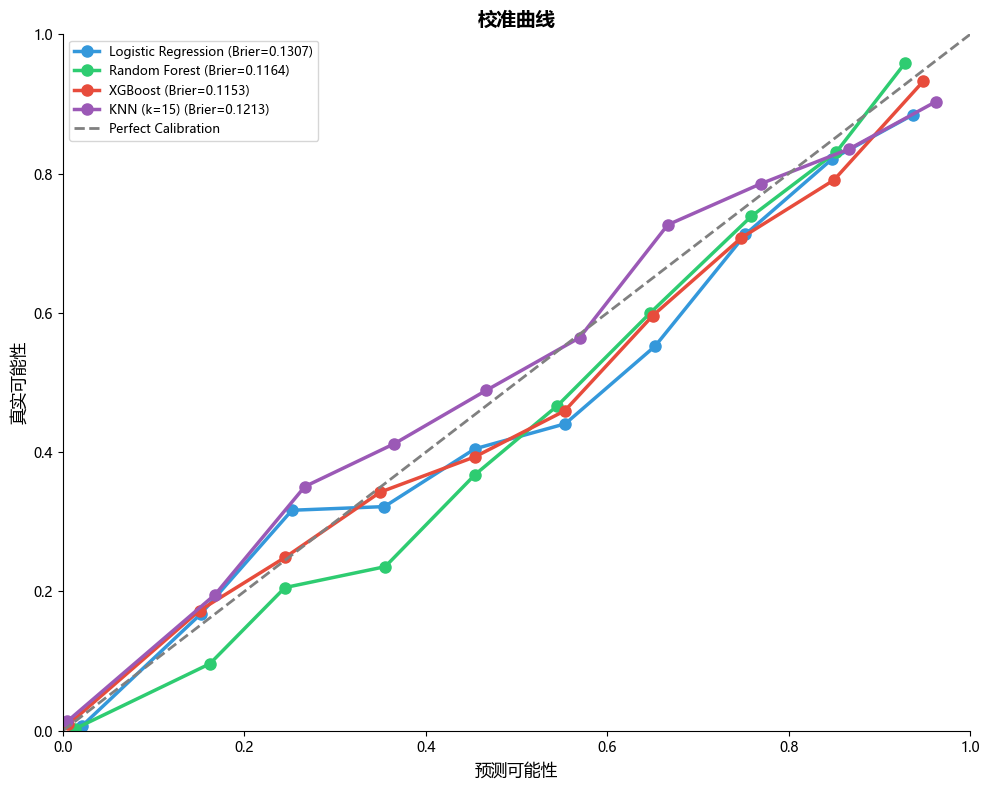

In [3]:
fig, ax = plt.subplots(figsize=(10, 8))
colors_cc = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for idx, (name, data) in enumerate(calibration_data.items()):
    ax.plot(data['prob_pred'], data['prob_true'], 'o-',
            color=colors_cc[idx % len(colors_cc)], linewidth=2.5,
            markersize=8, label=f"{name} (Brier={data['brier']:.4f})")

ax.plot([0, 1], [0, 1], '--', color='gray', linewidth=2, label='Perfect Calibration')
ax.set_xlabel('预测可能性', fontsize=12)
ax.set_ylabel('真实可能性', fontsize=12)
ax.set_title('校准曲线', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14a_calibration_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

In [4]:
print("\n  --- Hosmer-Lemeshow Goodness-of-Fit Test ---")

def hosmer_lemeshow_test(y_true, y_prob, n_groups=10):
    """
    Hosmer-Lemeshow 检验
    H0: 模型校准良好 (预测概率 = 实际比例)
    如果 p < 0.05 → 拒绝 H0 → 校准不良
    """
    from scipy.stats import chi2

    df_hl = pd.DataFrame({'y': y_true, 'prob': y_prob})
    df_hl['decile'] = pd.qcut(df_hl['prob'].rank(method='first'),
                               q=n_groups, labels=False)

    obs_pos = df_hl.groupby('decile')['y'].sum().values
    obs_neg = df_hl.groupby('decile')['y'].count().values - obs_pos
    exp_pos = df_hl.groupby('decile')['prob'].sum().values
    exp_neg = df_hl.groupby('decile')['prob'].count().values - exp_pos

    exp_pos = np.maximum(exp_pos, 1e-10)
    exp_neg = np.maximum(exp_neg, 1e-10)

    chi2_stat = np.sum((obs_pos - exp_pos)**2 / exp_pos +
                       (obs_neg - exp_neg)**2 / exp_neg)
    p_value = 1 - chi2.cdf(chi2_stat, n_groups - 2)

    return chi2_stat, p_value

hl_results = {}
for name, data in calibration_data.items():
    chi2, p = hosmer_lemeshow_test(y_te, data['y_prob'])
    hl_results[name] = {'chi2': chi2, 'p': p}
    print(f"  {name:<25}  χ²={chi2:.2f}  p={p:.4f}  {'良好' if p > 0.05 else '不良'}")


  --- Hosmer-Lemeshow Goodness-of-Fit Test ---
  Logistic Regression        χ²=112.03  p=0.0000  不良
  Random Forest              χ²=79.47  p=0.0000  不良
  XGBoost                    χ²=54.74  p=0.0000  不良
  KNN (k=15)                 χ²=170000000082.63  p=0.0000  不良


In [5]:
print("\n  --- Brier Score 分解 (Murphy分解) ---")

def brier_decomposition(y_true, y_prob):
    """Murphy分解: Brier = REFINEMENT + CALIBRATION + UNCERTAINTY"""
    y_bar = y_true.mean()
    uncertainty = y_bar * (1 - y_bar)

    n_bins = 10
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_indices = np.digitize(y_prob, bin_edges) - 1
    bin_indices = np.clip(bin_indices, 0, n_bins - 1)

    calibration = 0
    refinement = 0
    for bin_i in range(n_bins):
        mask = bin_indices == bin_i
        n_k = mask.sum()
        if n_k == 0:
            continue
        o_k = y_true[mask].mean()
        r_k = y_prob[mask].mean()
        calibration += n_k / len(y_true) * (o_k - r_k)**2
        refinement += n_k / len(y_true) * o_k * (1 - o_k)

    return refinement, calibration, uncertainty

print(f"  {'Model':<25} {'Brier':<10} {'鉴别力':<8} {'校准度':<8} {'不确定性':<10}")
print(f"  {'-'*25} {'-'*10} {'-'*8} {'-'*10} {'-'*10}")
for name, data in calibration_data.items():
    ref, cal, unc = brier_decomposition(y_te, data['y_prob'])
    brier = brier_score_loss(y_te, data['y_prob'])
    print(f"  {name:<25} {brier:.6f}   {ref:.6f}   {cal:.6f}   {unc:.6f}")


  --- Brier Score 分解 (Murphy分解) ---
  Model                     Brier      鉴别力      校准度      不确定性      
  ------------------------- ---------- -------- ---------- ----------
  Logistic Regression       0.130709   0.128286   0.002631   0.242168
  Random Forest             0.116411   0.115722   0.002002   0.242168
  XGBoost                   0.115295   0.114412   0.001618   0.242168
  KNN (k=15)                0.121326   0.120873   0.001162   0.242168


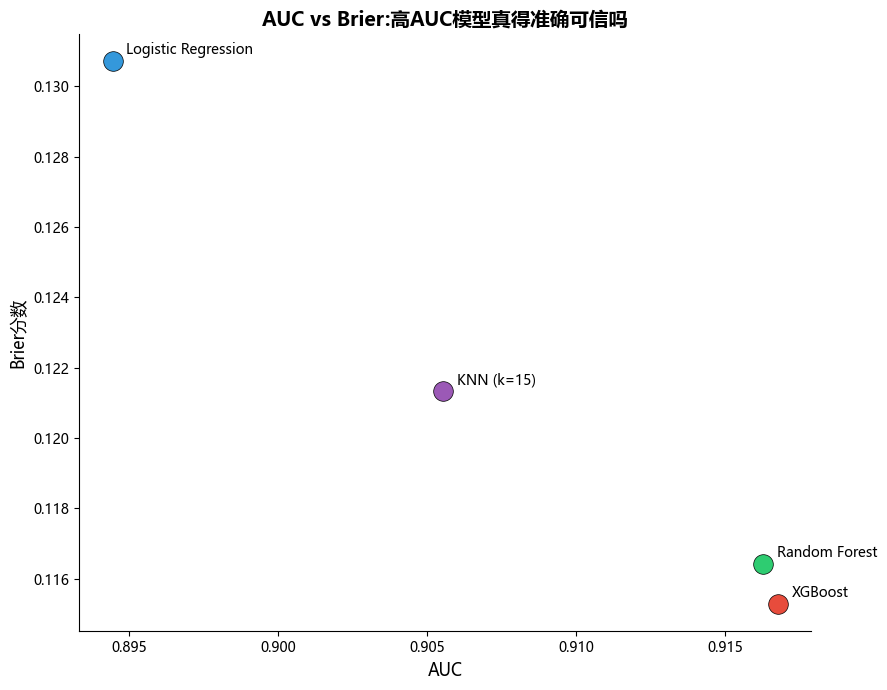

In [6]:
fig, ax = plt.subplots(figsize=(9, 7))
for name, data in calibration_data.items():
    ax.scatter(data['auc'], data['brier'], s=200,
               color=colors_cc[list(calibration_data.keys()).index(name)],
               edgecolors='black', linewidths=0.5, zorder=5)
    ax.annotate(name, (data['auc'], data['brier']),
                textcoords='offset points', xytext=(10, 5), fontsize=10)

ax.set_xlabel('AUC', fontsize=12)
ax.set_ylabel('Brier分数', fontsize=12)
ax.set_title('AUC vs Brier:高AUC模型真得准确可信吗',
             fontsize=14, fontweight='bold')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14b_auc_vs_brier.png"), dpi=150, bbox_inches='tight')
plt.show()

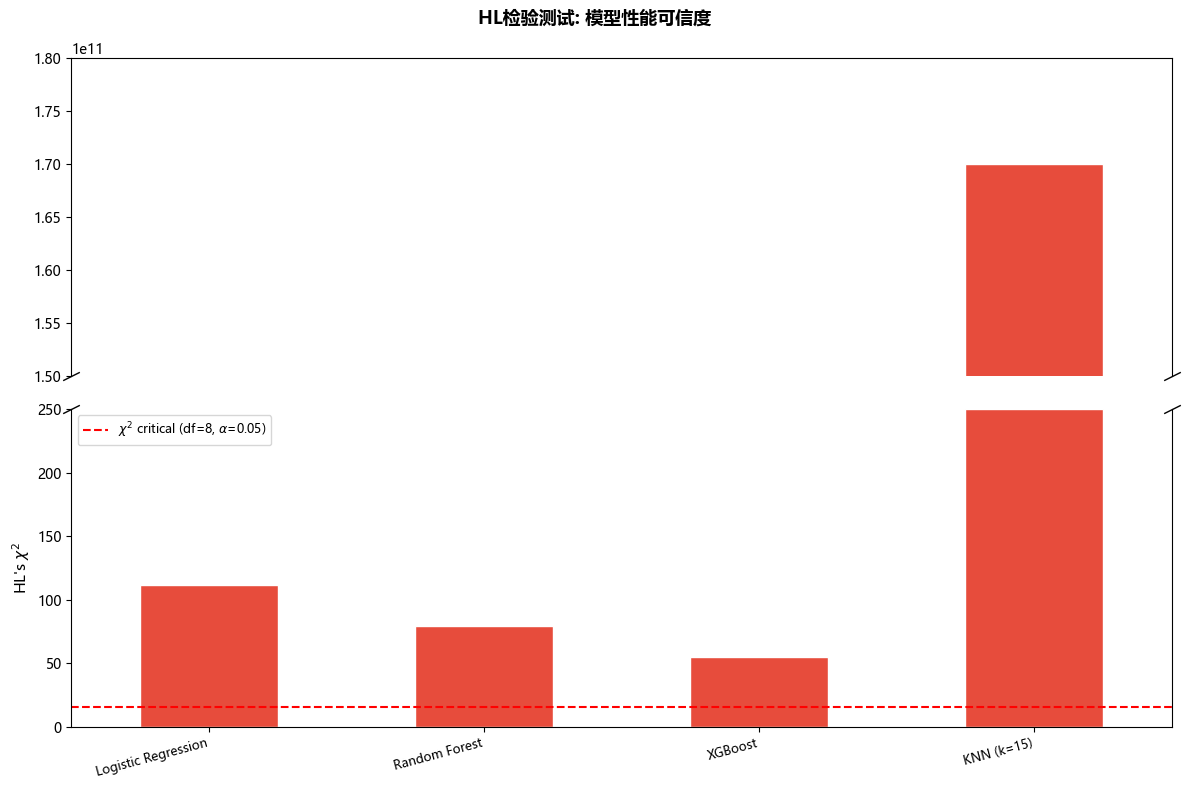

In [ ]:
names_hl = list(hl_results.keys())
chi2s = [hl_results[n]['chi2'] for n in names_hl]
ps = [hl_results[n]['p'] for n in names_hl]

fig, (ax1, ax2) = plt.subplots(2, 1, sharex=False, figsize=(12, 8))

ax1.set_ylim(1.5e11, 1.8e11)
ax2.set_ylim(0, 250)

ax1.spines.bottom.set_visible(False)
ax2.spines.top.set_visible(False)
ax1.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)

x_start = -0.5
x_end = len(names_hl) - 0.5
ax1.set_xlim(x_start, x_end)
ax2.set_xlim(x_start, x_end)

x_pos = range(len(names_hl))

bottom_cap_height = ax2.get_ylim()[1] 

for i, (x, chi, p) in enumerate(zip(x_pos, chi2s, ps)):
    color = '#2ecc71' if p > 0.05 else '#e74c3c'
    if chi > 250:
        ax1.bar(x, chi, color=color, edgecolor='white', width=0.5)
        ax2.bar(x, bottom_cap_height, color=color, edgecolor='white', width=0.5)
    else:
        ax2.bar(x, chi, color=color, edgecolor='white', width=0.5)

ax2.axhline(y=15.507, color='red', linestyle='--', linewidth=1.5, label=r'$\chi^2$ critical (df=8, $\alpha$=0.05)')
ax1.axhline(y=15.507, color='red', linestyle='--', linewidth=1.5)

d = 0.5
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=12, linestyle="none", color='k', mec='k', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0], transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

ax2.set_xticks(range(len(names_hl)))
ax2.set_xticklabels(names_hl, rotation=15, ha='right', fontsize=9)

ax2.set_ylabel(r"HL's $\chi^2$", fontsize=11)
fig.suptitle('HL检验测试: 模型性能可信度', fontsize=13, fontweight='bold')
ax2.legend(fontsize=9, loc='upper left')

plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14c_hl_test_native_broken_axis.png"), dpi=150, bbox_inches='tight')
plt.show()

In [16]:
def dca_net_benefit(y_true, y_prob, thresholds):
    """
    计算 DCA 的净获益 (Net Benefit)
    NB = TP/N - FP/N × (pt / (1-pt))

    参数:
      y_true: 真实标签 (1=正类)
      y_prob: 预测概率
      thresholds: 风险阈值数组

    返回:
      net_benefits: 各阈值下的净获益
    """
    N = len(y_true)
    net_benefits = []

    for pt in thresholds:
        y_pred = (y_prob >= pt).astype(int)
        TP = ((y_pred == 1) & (y_true == 1)).sum()
        FP = ((y_pred == 1) & (y_true == 0)).sum()

        if pt == 0 or pt == 1:
            nb = 0
        else:
            nb = TP / N - FP / N * (pt / (1 - pt))
        net_benefits.append(nb)

    return np.array(net_benefits)

def dca_treat_all(y_true, thresholds):
    """所有患者都干预的净获益"""
    N = len(y_true)
    n_pos = (y_true == 1).sum()
    net_benefits = []
    for pt in thresholds:
        if pt == 0 or pt == 1:
            nb = 0
        else:
            TP = n_pos
            FP = N - n_pos
            nb = TP / N - FP / N * (pt / (1 - pt))
        net_benefits.append(nb)
    return np.array(net_benefits)

def dca_treat_none(y_true, thresholds):
    """所有患者都不干预的净获益 = 0"""
    return np.zeros(len(thresholds))

thresholds = np.linspace(0.01, 0.99, 99)

dca_results = {}

for name, data in calibration_data.items():
    dca_results[name] = dca_net_benefit(y_te, data['y_prob'], thresholds)

nb_treat_all = dca_treat_all(y_te, thresholds)
nb_treat_none = dca_treat_none(y_te, thresholds)

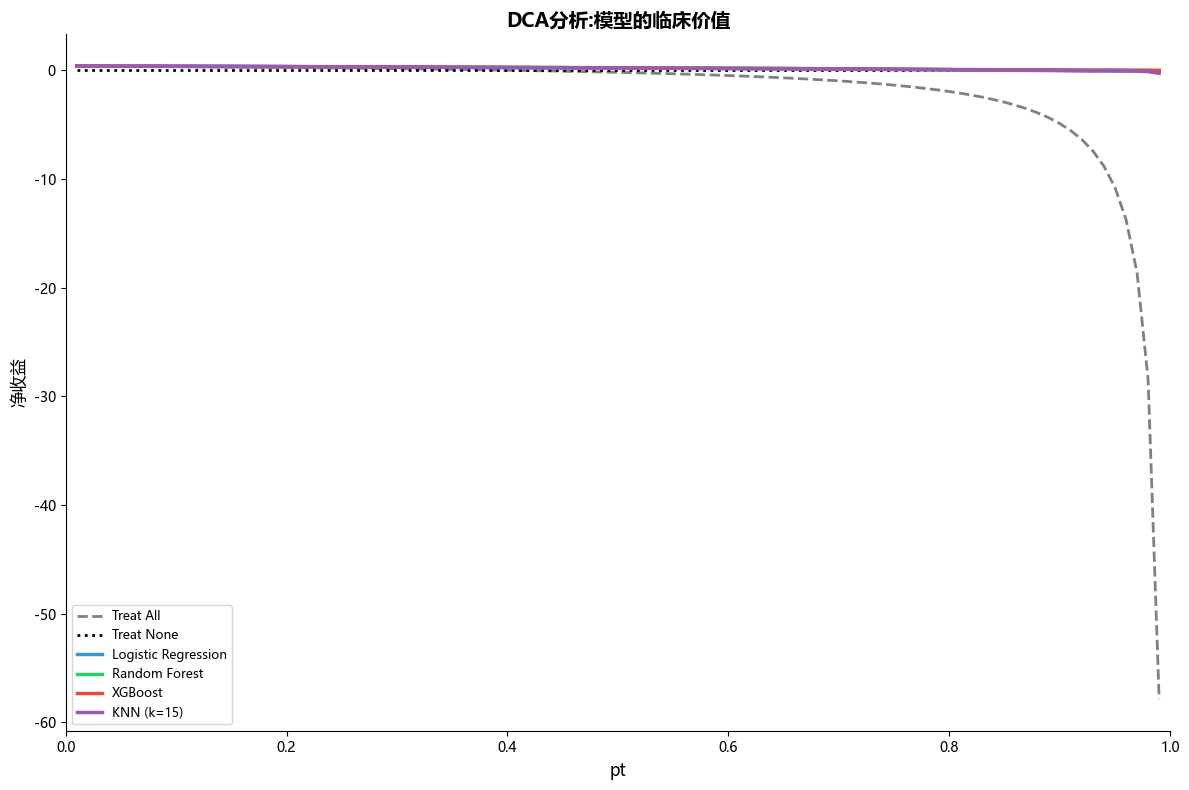

In [18]:
fig, ax = plt.subplots(figsize=(12, 8))

ax.plot(thresholds, nb_treat_all, '--', color='gray', linewidth=2,
        label='Treat All')
ax.plot(thresholds, nb_treat_none, ':', color='black', linewidth=2,
        label='Treat None')

for idx, (name, nb) in enumerate(dca_results.items()):
    ax.plot(thresholds, nb, '-', color=colors_cc[idx % len(colors_cc)],
            linewidth=2.5, label=f'{name}')

ax.set_xlabel('pt', fontsize=12)
ax.set_ylabel('净收益', fontsize=12)
ax.set_title('DCA分析:模型的临床价值',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='lower left')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.set_xlim([0, 1])
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14d_dca_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

In [21]:
print("\n  --- 临床获益范围分析 ---")
for name, nb in dca_results.items():
    better_than_none = nb > nb_treat_none
    better_than_all = nb > nb_treat_all
    beneficial = better_than_none & better_than_all

    if beneficial.any():
        idx_beneficial = np.where(beneficial)[0]
        pt_start = thresholds[idx_beneficial[0]]
        pt_end = thresholds[idx_beneficial[-1]]
        max_nb = nb.max()
        max_nb_pt = thresholds[nb.argmax()]
        print(f"  {name:<25}")
        print(f"    获益范围: pt ∈ [{pt_start:.2f}, {pt_end:.2f}]")
        print(f"    最大净获益: {max_nb:.6f} (pt = {max_nb_pt:.2f})")
    else:
        print(f"  {name:<25} 未发现临床获益范围")


  --- 临床获益范围分析 ---
  Logistic Regression      
    获益范围: pt ∈ [0.01, 0.87]
    最大净获益: 0.406877 (pt = 0.01)
  Random Forest            
    获益范围: pt ∈ [0.01, 0.97]
    最大净获益: 0.407311 (pt = 0.01)
  XGBoost                  
    获益范围: pt ∈ [0.01, 0.98]
    最大净获益: 0.408833 (pt = 0.01)
  KNN (k=15)               
    获益范围: pt ∈ [0.01, 0.90]
    最大净获益: 0.407786 (pt = 0.01)


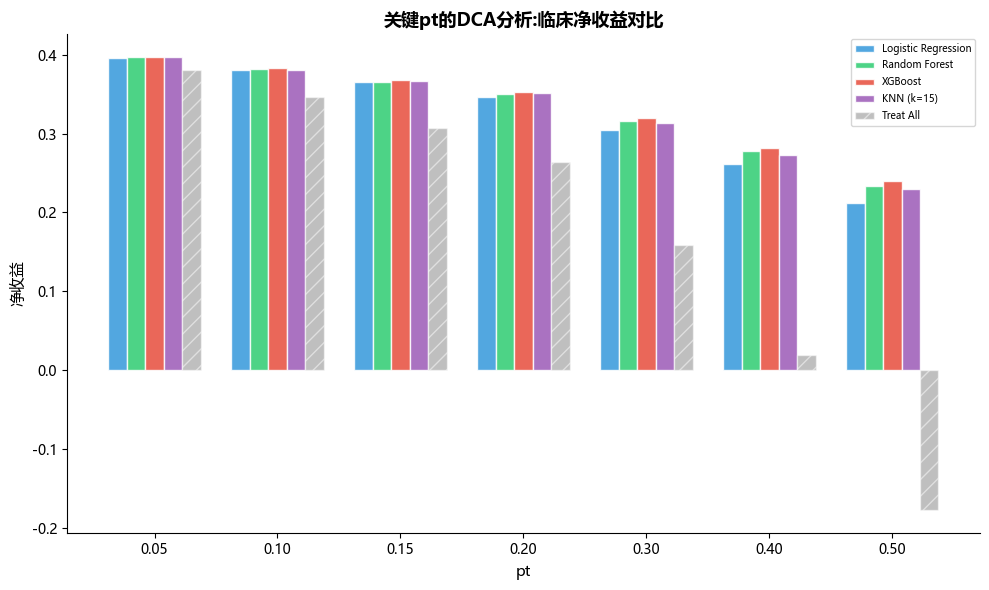

In [23]:
fig, ax = plt.subplots(figsize=(10, 6))
selected_thresholds = [0.05, 0.10, 0.15, 0.20, 0.30, 0.40, 0.50]
x_labels = [f'{pt:.2f}' for pt in selected_thresholds]
x_pos = np.arange(len(x_labels))
width_dca = 0.15

for idx, (name, data) in enumerate(calibration_data.items()):
    nb_vals = []
    for pt in selected_thresholds:
        y_pred = (data['y_prob'] >= pt).astype(int)
        TP = ((y_pred == 1) & (y_te == 1)).sum()
        FP = ((y_pred == 1) & (y_te == 0)).sum()
        N = len(y_te)
        if pt <= 0 or pt >= 1:
            nb_vals.append(0)
        else:
            nb_vals.append(TP/N - FP/N * (pt/(1-pt)))
    ax.bar(x_pos + (idx - 2) * width_dca, nb_vals, width_dca,
           color=colors_cc[idx % len(colors_cc)],
           edgecolor='white', label=name, alpha=0.85)

nb_all_vals = []
for pt in selected_thresholds:
    N = len(y_te); n_p = (y_te == 1).sum()
    nb_all_vals.append(n_p/N - (N-n_p)/N * (pt/(1-pt)) if 0 < pt < 1 else 0)
ax.bar(x_pos + (len(calibration_data) - 2) * width_dca, nb_all_vals, width_dca,
       color='gray', edgecolor='white', label='Treat All', alpha=0.5, hatch='//')

ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels)
ax.set_xlabel('pt', fontsize=11)
ax.set_ylabel('净收益', fontsize=11)
ax.set_title('关键pt的DCA分析:临床净收益对比',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=7, loc='upper right')
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(os.path.join(IMG_DIR, "14e_dca_thresholds.png"), dpi=150, bbox_inches='tight')
plt.show()